In [ ]:
!pip install prophet tensorflow


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from prophet import Prophet
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("/content/gold_prices_10y (1).csv")   # replace with your filename
print("Columns:", df.columns)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Detect numeric column automatically
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) == 0:
    raise ValueError("No numeric columns found in dataset!")

target_col = numeric_cols[0]   # use first numeric column
print("Using column:", target_col)

df.rename(columns={target_col:'gold_price'}, inplace=True)
print(df.head())


Saving gold_prices_10y (1).csv to gold_prices_10y (1) (2).csv
Columns: Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Adj Close',
       'Daily_Return', 'MA_20', 'MA_50', 'MA_200', 'Volatility_20', 'Year',
       'Month', 'Day_of_Week', 'Quarter'],
      dtype='object')
Using column: Close
            gold_price        High         Low        Open    Volume  \
Date                                                                   
2016-01-29  106.949997  107.000000  106.260002  106.610001   8098700   
2016-02-01  108.050003  108.150002  107.529999  107.540001  10471800   
2016-02-02  108.089996  108.180000  107.349998  107.919998   6656000   
2016-02-03  109.250000  109.580002  107.900002  107.910004  15785200   
2016-02-04  110.570000  110.699997  109.919998  110.449997  13213700   

             Adj Close  Daily_Return  MA_20  MA_50  MA_200  Volatility_20  \
Date                                                                        
2016-01-29  106.949997           NaN   

/tmp/ipykernel_7400/336038679.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


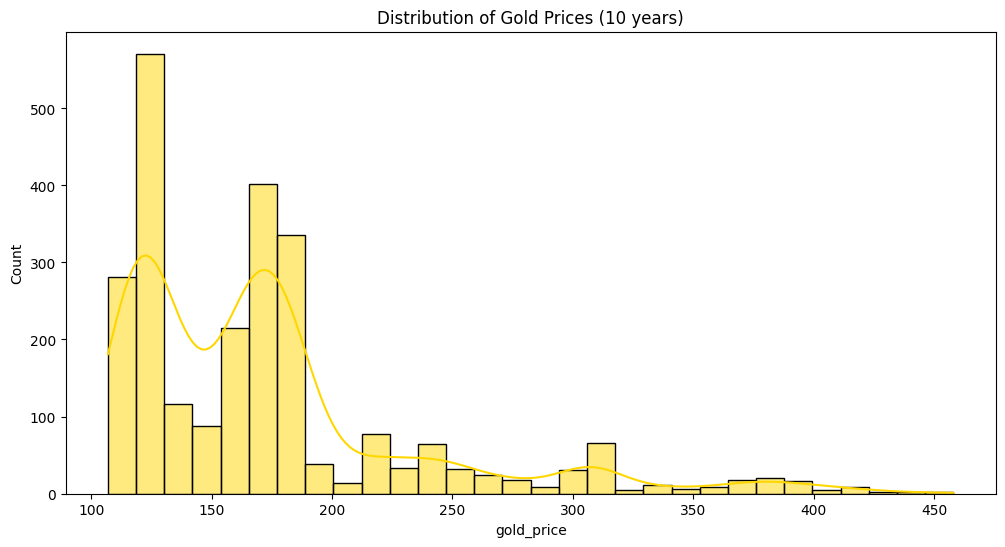

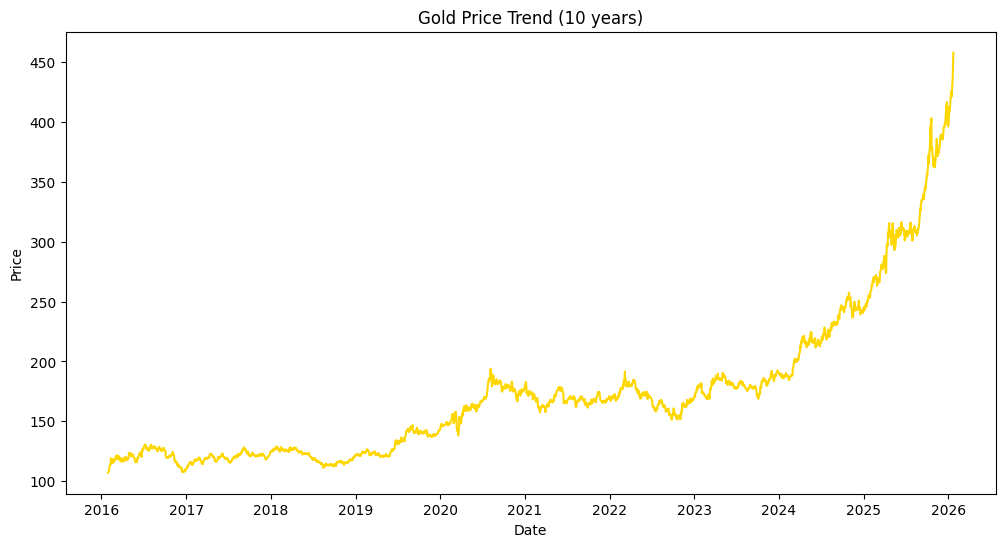

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df['gold_price'], bins=30, color="gold", kde=True)
plt.title("Distribution of Gold Prices (10 years)")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df.index, df['gold_price'], color="gold")
plt.title("Gold Price Trend (10 years)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

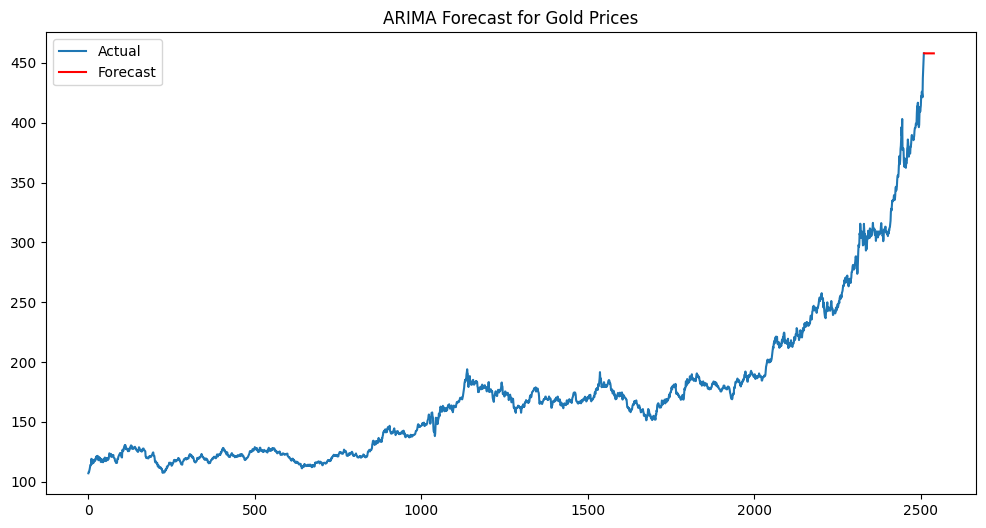

In [ ]:
model = ARIMA(df['gold_price'], order=(2,1,2))
model_fit = model.fit()
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(12,6))
plt.plot(df['gold_price'].values, label="Actual")
plt.plot(range(len(df), len(df)+30), forecast, label="Forecast", color="red")
plt.title("ARIMA Forecast for Gold Prices")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


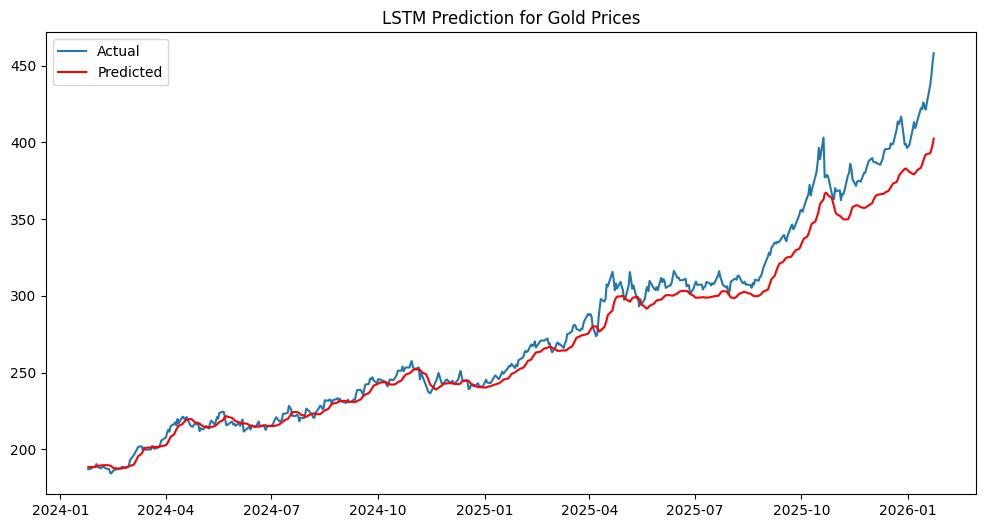

In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df['gold_price'].values.reshape(-1,1))

X, y = [], []
time_steps = 10

for i in range(time_steps, len(scaled)):
    X.append(scaled[i-time_steps:i, 0])
    y.append(scaled[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

pred_lstm = model_lstm.predict(X_test)
pred_lstm = scaler.inverse_transform(pred_lstm)

plt.figure(figsize=(12,6))
plt.plot(df.index[-len(y_test):], scaler.inverse_transform(y_test.reshape(-1,1)), label="Actual")
plt.plot(df.index[-len(y_test):], pred_lstm, label="Predicted", color="red")
plt.title("LSTM Prediction for Gold Prices")
plt.legend()
plt.show()
